## Section 1: Setup and Data Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110

# na_values ensures empty strings and bare NaN text are proper nulls,
# not left as float nan in string-typed columns
df = pd.read_csv(
    '../data_source/customer_support_tickets.csv',
    na_values=['', 'NaN', 'nan', 'NULL', 'N/A']
)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.head(3)

Shape: (61765, 16)

Dtypes:
subject         str
body            str
answer          str
type            str
queue           str
priority        str
language        str
version     float64
tag_1           str
tag_2           str
tag_3           str
tag_4           str
tag_5           str
tag_6           str
tag_7           str
tag_8           str
dtype: object

Null counts:
subject      5299
body            2
answer      13189
type        13178
queue           0
priority        0
language        0
version     33178
tag_1       13178
tag_2       13237
tag_3       13409
tag_4       17775
tag_5       34129
tag_6       48540
tag_7       55797
tag_8       59293
dtype: int64

Duplicate rows: 0


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


## Section 2: Missing Value Analysis

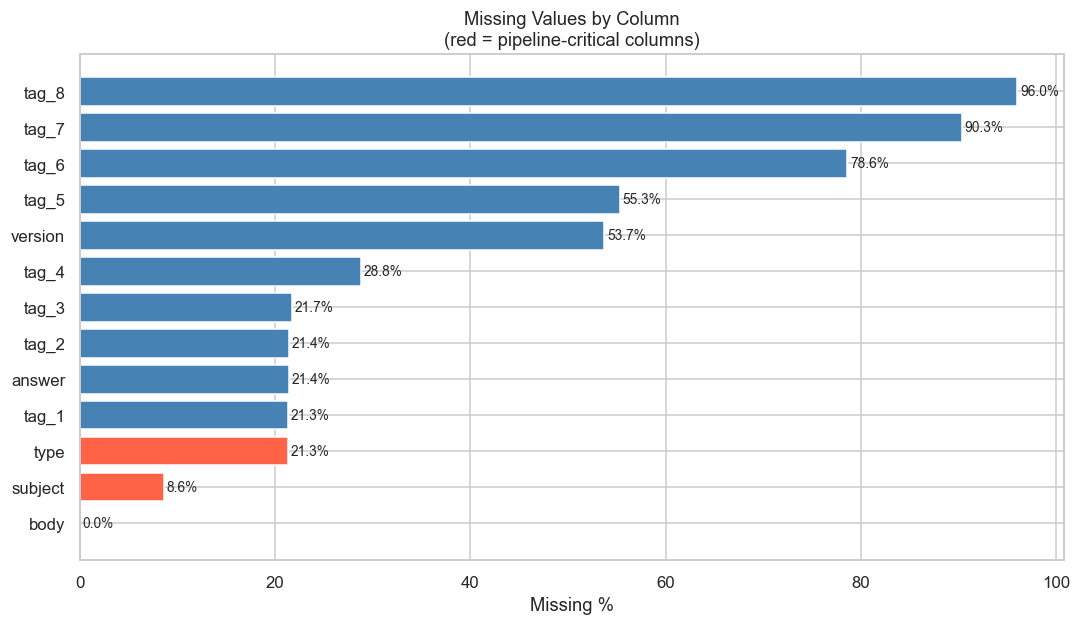


Pipeline-critical column nulls:
  subject     : 5,299 nulls (8.6%)
  body        : 2 nulls (0.0%)
  priority    : 0 nulls (0.0%)
  type        : 13,178 nulls (21.3%)
  queue       : 0 nulls (0.0%)
  language    : 0 nulls (0.0%)


In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=True)

# Colour-code pipeline-critical columns
PIPELINE_COLS = ['subject', 'body', 'priority', 'type', 'queue', 'language']
colours = ['tomato' if c in PIPELINE_COLS else 'steelblue'
           for c in missing_df.index]

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.45)))
bars = ax.barh(missing_df.index, missing_df['pct'], color=colours)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column\n(red = pipeline-critical columns)')
for bar, pct in zip(bars, missing_df['pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nPipeline-critical column nulls:")
for c in PIPELINE_COLS:
    n = int(df[c].isnull().sum())
    print(f"  {c:12s}: {n:,} nulls ({n/len(df)*100:.1f}%)")

## Section 3: Priority Distribution

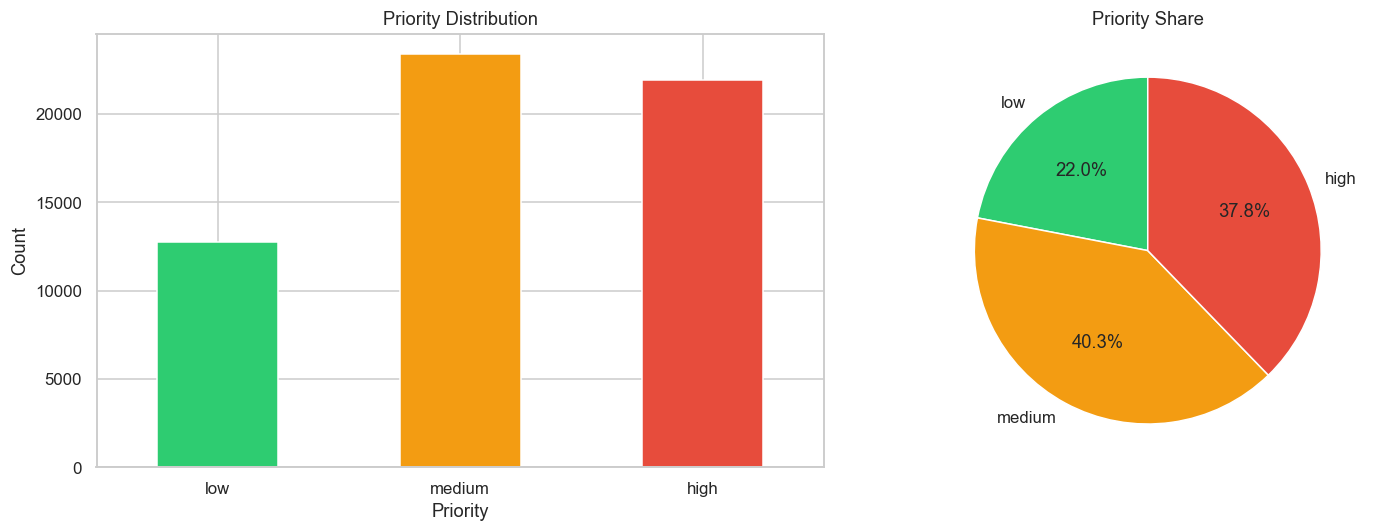

INSIGHT: Priority distribution is BALANCED
  Dominant: 'medium' at 37.8%
  No skew — priority contributes clean ordinal signal to operational features


In [3]:
# Enforce logical order low → medium → high
priority_order = ['low', 'medium', 'high']
priority_counts = df['priority'].value_counts().reindex(priority_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
priority_counts.plot(kind='bar', ax=axes[0],
                     color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[0].set_title('Priority Distribution')
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

priority_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                     colors=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Priority Share')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

dominant = priority_counts.idxmax()
pct = priority_counts.max() / len(df) * 100
print(f"INSIGHT: Priority distribution is {'SKEWED' if pct > 50 else 'BALANCED'}")
print(f"  Dominant: '{dominant}' at {pct:.1f}%")
if pct > 50:
    print("  Impact: KMeans clusters may reflect priority skew rather than issue type")
    print("  Recommendation: Downweight 'priority' in operational features (lower alpha)")
else:
    print("  No skew — priority contributes clean ordinal signal to operational features")

## Section 4: Ticket Type Distribution

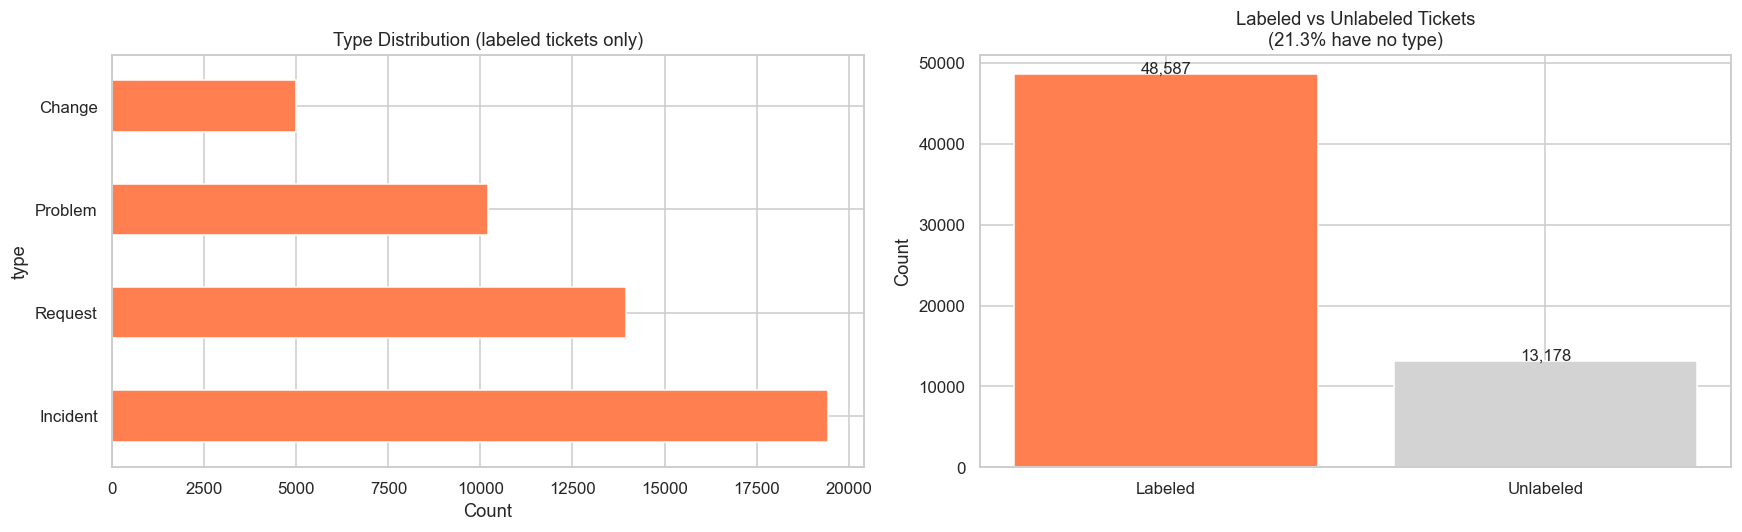

Unique ticket types (excluding nulls): 4
Unlabeled tickets: 13,178 (21.3%)

Type counts:
type
Incident    19444
Request     13950
Problem     10196
Change       4997

INSIGHT: ~21% of tickets have no type label. One-hot encoding 'type' will
  produce a NaN category. preprocessing.py already fills nulls with empty
  string for text; operational_features.py needs to handle NaN in get_dummies.


In [4]:
type_counts = df['type'].value_counts(dropna=False)
n_nulls = int(df['type'].isnull().sum())
null_pct = n_nulls / len(df) * 100

# Separate labeled vs unlabeled
labeled = df['type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labeled.plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Type Distribution (labeled tickets only)')
axes[0].set_xlabel('Count')

# Show labeled vs unlabeled split
axes[1].bar(['Labeled', 'Unlabeled'], [len(df) - n_nulls, n_nulls],
             color=['coral', 'lightgray'], edgecolor='white')
axes[1].set_title(f'Labeled vs Unlabeled Tickets\n({null_pct:.1f}% have no type)')
axes[1].set_ylabel('Count')
for i, v in enumerate([len(df) - n_nulls, n_nulls]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Unique ticket types (excluding nulls): {df['type'].nunique()}")
print(f"Unlabeled tickets: {n_nulls:,} ({null_pct:.1f}%)")
print("\nType counts:")
print(labeled.to_string())
print("\nINSIGHT: ~21% of tickets have no type label. One-hot encoding 'type' will")
print("  produce a NaN category. preprocessing.py already fills nulls with empty")
print("  string for text; operational_features.py needs to handle NaN in get_dummies.")

## Section 5: Queue Distribution

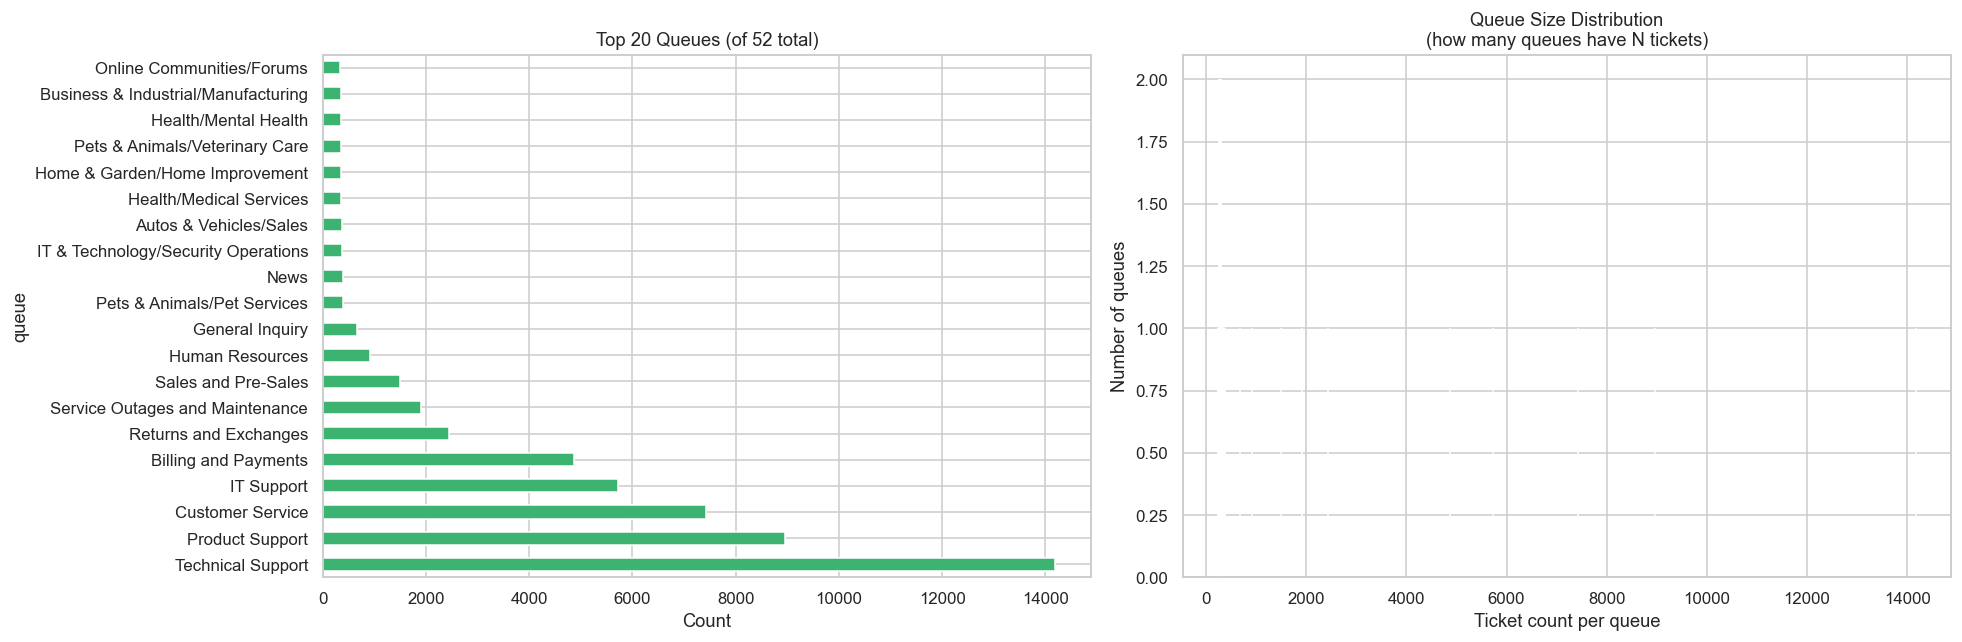

Unique queues: 52
Largest queue: 'Technical Support' (14,186 tickets)
Smallest queue: 'Real Estate' (230 tickets)
Max/min imbalance ratio: 61.7x

INSIGHT: 52 unique queues → one-hot would create 52 sparse columns
  Frequency encoding collapses this to 1 dense column (config already set)


In [5]:
queue_counts = df['queue'].value_counts()
n_queues = df['queue'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20
queue_counts.head(20).plot(kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title(f'Top 20 Queues (of {n_queues} total)')
axes[0].set_xlabel('Count')

# Frequency distribution: how many queues have how many tickets
freq_dist = queue_counts.value_counts().sort_index()
axes[1].bar(freq_dist.index, freq_dist.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Queue Size Distribution\n(how many queues have N tickets)')
axes[1].set_xlabel('Ticket count per queue')
axes[1].set_ylabel('Number of queues')
plt.tight_layout()
plt.show()

print(f"Unique queues: {n_queues}")
print(f"Largest queue: '{queue_counts.index[0]}' ({queue_counts.iloc[0]:,} tickets)")
print(f"Smallest queue: '{queue_counts.index[-1]}' ({queue_counts.iloc[-1]:,} tickets)")
imbalance = queue_counts.iloc[0] / queue_counts.iloc[-1]
print(f"Max/min imbalance ratio: {imbalance:.1f}x")
print(f"\nINSIGHT: {n_queues} unique queues → one-hot would create {n_queues} sparse columns")
print("  Frequency encoding collapses this to 1 dense column (config already set)")

## Section 6: Language Distribution

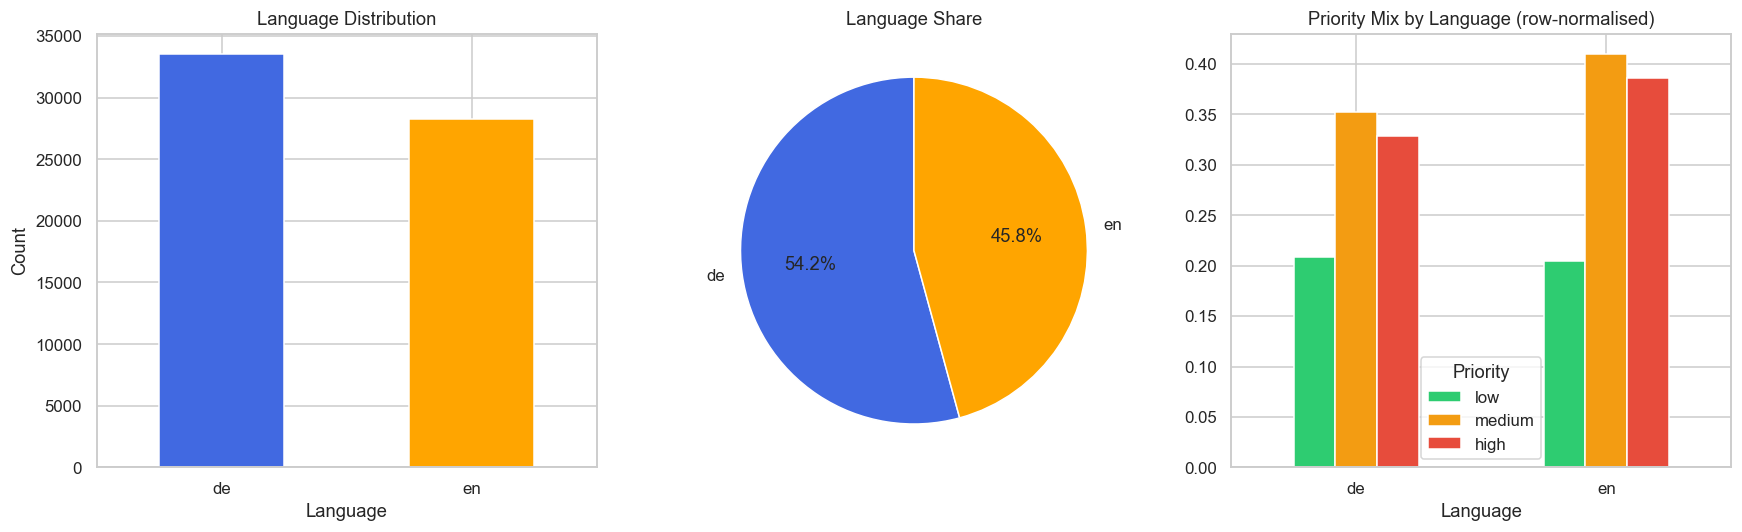

English tickets: 28,261 (45.8%)
German tickets:  33,504 (54.2%)

INSIGHT: Bilingual corpus — all-mpnet-base-v2 handles multilingual text but
  domain_keywords in config.yaml are English-only. German tickets may have
  weaker domain keyword preservation during cleaning.
  'language' as a binary feature adds a clean one-hot signal to operational features.


In [6]:
lang_counts = df['language'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lang_counts.plot(kind='bar', ax=axes[0], color=['royalblue', 'orange'], edgecolor='white')
axes[0].set_title('Language Distribution')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

lang_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                 colors=['royalblue', 'orange'])
axes[1].set_title('Language Share')
axes[1].set_ylabel('')

# Priority breakdown by language
lang_prio = pd.crosstab(df['language'], df['priority'], normalize='index')
lang_prio[['low', 'medium', 'high']].plot(kind='bar', ax=axes[2],
    color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[2].set_title('Priority Mix by Language (row-normalised)')
axes[2].set_xlabel('Language')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Priority')
plt.tight_layout()
plt.show()

en_pct = lang_counts.get('en', 0) / len(df) * 100
de_pct = lang_counts.get('de', 0) / len(df) * 100
print(f"English tickets: {lang_counts.get('en', 0):,} ({en_pct:.1f}%)")
print(f"German tickets:  {lang_counts.get('de', 0):,} ({de_pct:.1f}%)")
print("\nINSIGHT: Bilingual corpus — all-mpnet-base-v2 handles multilingual text but")
print("  domain_keywords in config.yaml are English-only. German tickets may have")
print("  weaker domain keyword preservation during cleaning.")
print("  'language' as a binary feature adds a clean one-hot signal to operational features.")

## Section 7: Text Length Analysis

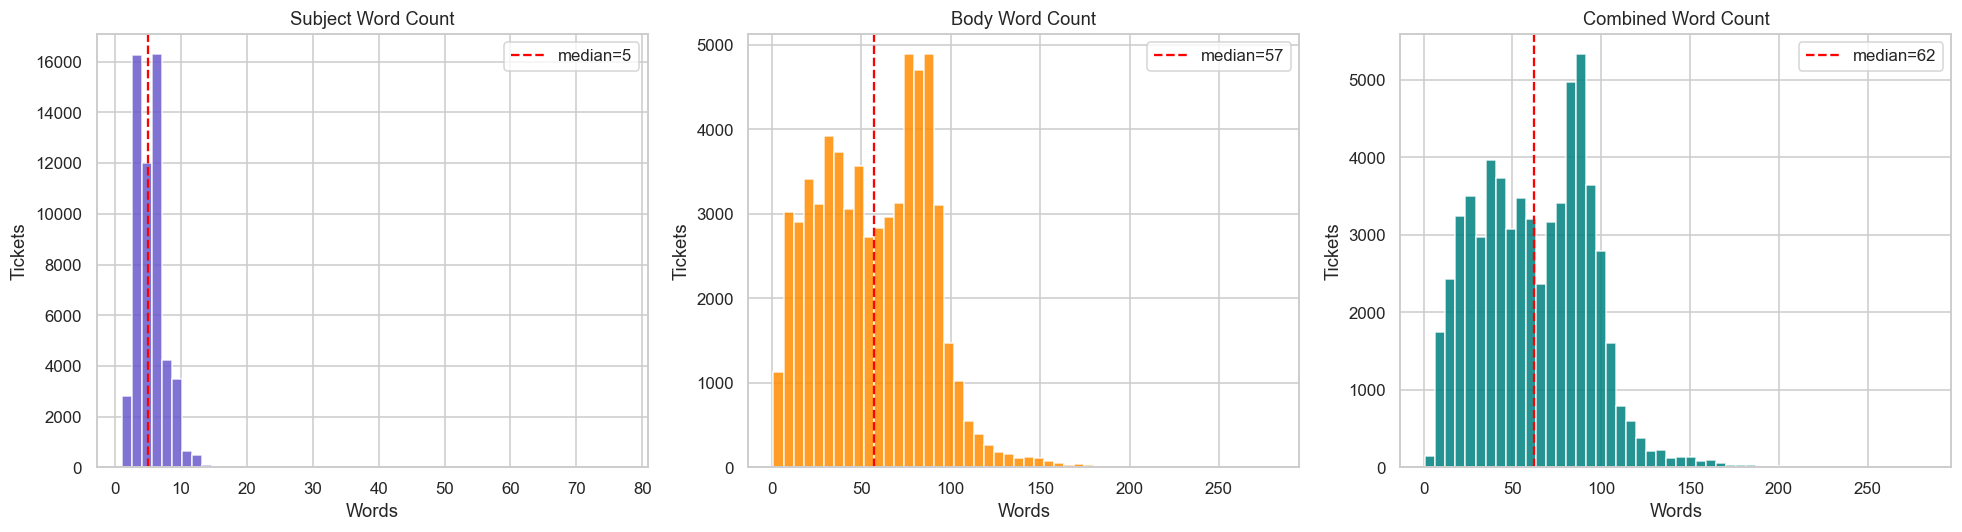

subject_len  — median: 5  max: 77
body_len     — median: 57  max: 281
combined_len — median: 62  max: 283

Tickets with empty subject (null): 8.6%
Tickets with <5 combined words: 0.1%
Tickets exceeding 512 tokens: 0.0%


In [7]:
df['subject_len'] = df['subject'].fillna('').str.split().str.len()
df['body_len']    = df['body'].fillna('').str.split().str.len()
df['combined_len'] = df['subject_len'] + df['body_len']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    ('subject_len',  'Subject Word Count',  'slateblue'),
    ('body_len',     'Body Word Count',      'darkorange'),
    ('combined_len', 'Combined Word Count',  'teal'),
]
for ax, (col, title, colour) in zip(axes, configs):
    ax.hist(df[col][df[col] > 0], bins=50, color=colour, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'median={df[col].median():.0f}')
    ax.set_title(title)
    ax.set_xlabel('Words')
    ax.set_ylabel('Tickets')
    ax.legend()
plt.tight_layout()
plt.show()

TRANSFORMER_MAX = 512
short_threshold = 5
missing_subj_pct = (df['subject_len'] == 0).mean() * 100
short_pct = (df['combined_len'] < short_threshold).mean() * 100
over_limit = (df['combined_len'] > TRANSFORMER_MAX).mean() * 100

print(f"subject_len  — median: {df['subject_len'].median():.0f}  max: {df['subject_len'].max()}")
print(f"body_len     — median: {df['body_len'].median():.0f}  max: {df['body_len'].max()}")
print(f"combined_len — median: {df['combined_len'].median():.0f}  max: {df['combined_len'].max()}")
print(f"\nTickets with empty subject (null): {missing_subj_pct:.1f}%")
print(f"Tickets with <{short_threshold} combined words: {short_pct:.1f}%")
print(f"Tickets exceeding {TRANSFORMER_MAX} tokens: {over_limit:.1f}%")
if over_limit > 0:
    print(f"  INSIGHT: all-mpnet-base-v2 will truncate these — long body text will be cut")

## Section 8: Tag Analysis

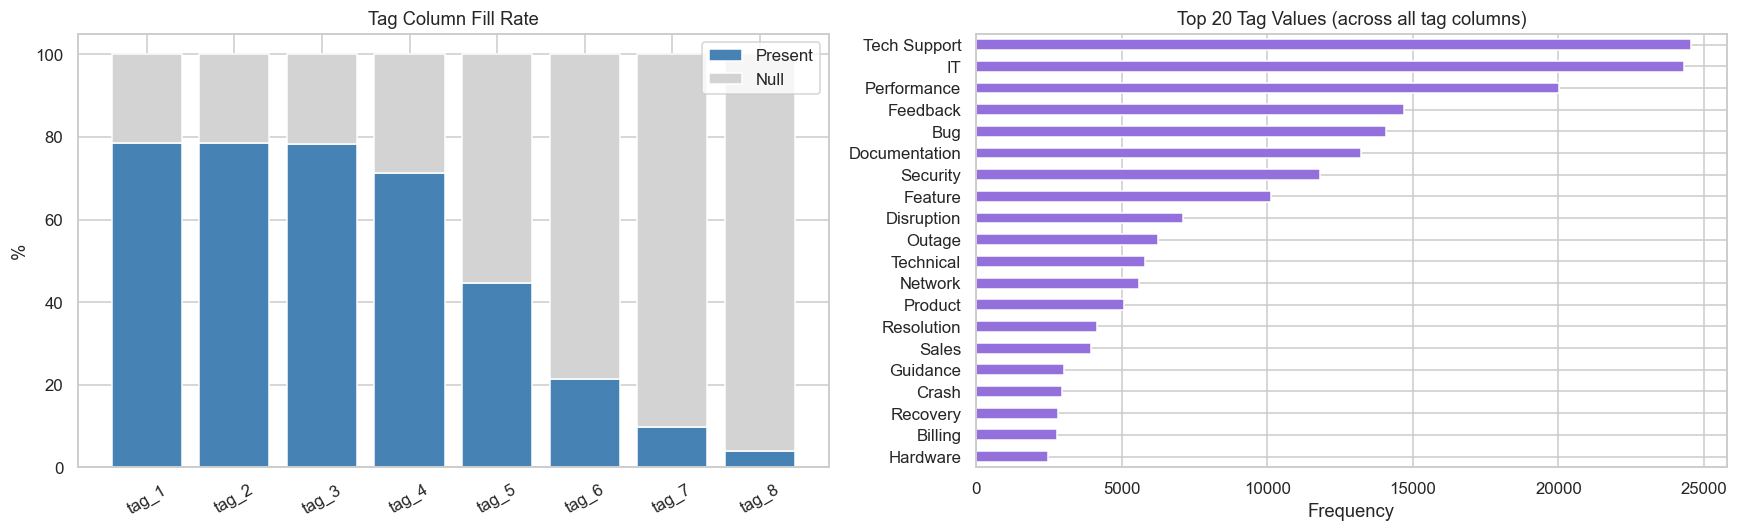

Tag fill rates:
  tag_1: 78.7% filled, 211 unique values
  tag_2: 78.6% filled, 350 unique values
  tag_3: 78.3% filled, 591 unique values
  tag_4: 71.2% filled, 831 unique values
  tag_5: 44.7% filled, 956 unique values
  tag_6: 21.4% filled, 920 unique values
  tag_7: 9.7% filled, 755 unique values
  tag_8: 4.0% filled, 512 unique values

INSIGHT: Tags are hierarchical — tag_1 always present when any tag exists,
  tag_6/7/8 near-empty (<10% fill). Tags are NOT used as pipeline features
  but are valuable for post-hoc cluster labelling and business interpretation.


In [8]:
tag_cols = [c for c in df.columns if c.startswith('tag_')]
tag_null_pcts = [(c, df[c].isnull().mean() * 100) for c in tag_cols]

# Sparsity overview
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names, nulls = zip(*tag_null_pcts)
presence = [100 - n for n in nulls]
axes[0].bar(names, presence, color='steelblue', edgecolor='white', label='Present')
axes[0].bar(names, nulls, bottom=presence, color='lightgray', edgecolor='white', label='Null')
axes[0].set_title('Tag Column Fill Rate')
axes[0].set_ylabel('%')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Most common values across all tags combined
from collections import Counter
all_tags = Counter()
for col in tag_cols:
    all_tags.update(df[col].dropna().value_counts().to_dict())
top_tags = pd.Series(dict(all_tags.most_common(20)))
top_tags.sort_values().plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Top 20 Tag Values (across all tag columns)')
axes[1].set_xlabel('Frequency')
plt.tight_layout()
plt.show()

print("Tag fill rates:")
for col, null_pct in tag_null_pcts:
    n_unique = df[col].nunique()
    print(f"  {col}: {100-null_pct:.1f}% filled, {n_unique} unique values")
print("\nINSIGHT: Tags are hierarchical — tag_1 always present when any tag exists,")
print("  tag_6/7/8 near-empty (<10% fill). Tags are NOT used as pipeline features")
print("  but are valuable for post-hoc cluster labelling and business interpretation.")

## Section 9: Cross-tabulations

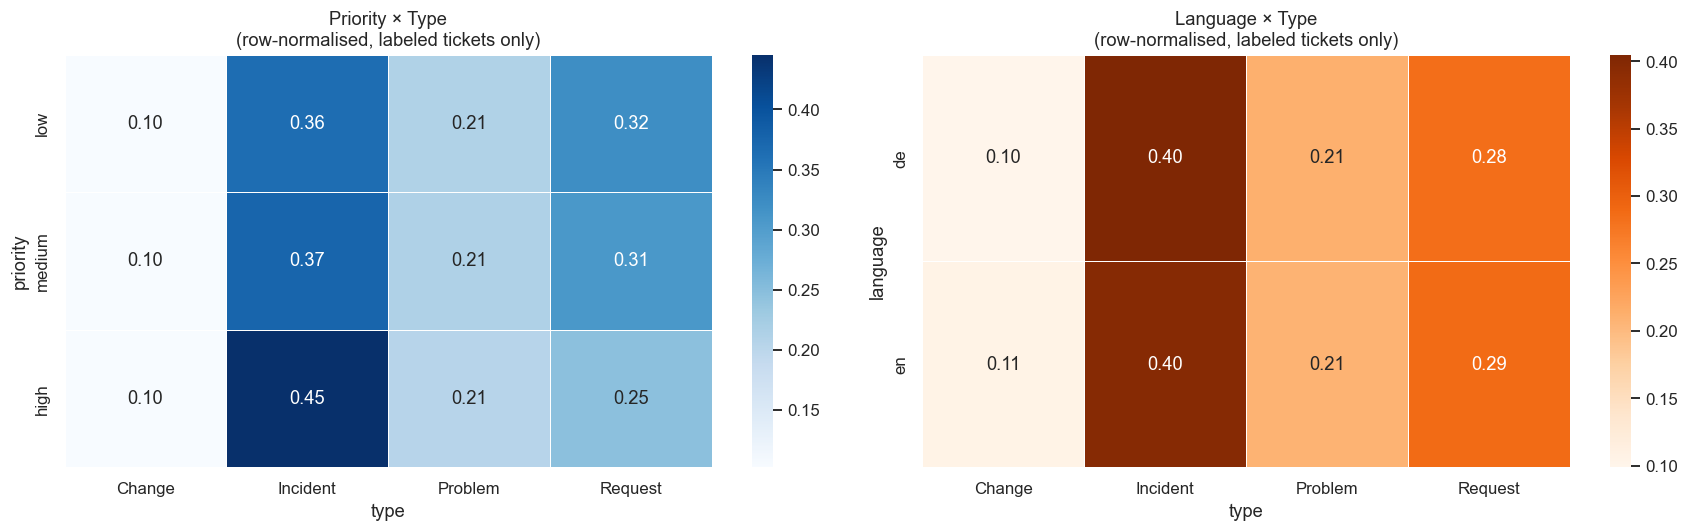

Priority × Type insights:
  low   : most common type is 'Incident' (36%)
  medium: most common type is 'Incident' (37%)
  high  : most common type is 'Incident' (45%)

Language × Type insights:
  de: most common type is 'Incident' (40%)
  en: most common type is 'Incident' (40%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Priority x Type (labeled tickets only)
labeled_df = df.dropna(subset=['type'])
crosstab_pt = pd.crosstab(labeled_df['priority'], labeled_df['type'], normalize='index')
# Enforce priority row order
for idx in ['low', 'medium', 'high']:
    if idx not in crosstab_pt.index:
        crosstab_pt.loc[idx] = 0
crosstab_pt = crosstab_pt.reindex(['low', 'medium', 'high'])
sns.heatmap(crosstab_pt, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Priority × Type\n(row-normalised, labeled tickets only)')

# Language x Type
crosstab_lt = pd.crosstab(labeled_df['language'], labeled_df['type'], normalize='index')
sns.heatmap(crosstab_lt, annot=True, fmt='.2f', cmap='Oranges',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Language × Type\n(row-normalised, labeled tickets only)')

plt.tight_layout()
plt.show()

print("Priority × Type insights:")
for prio in ['low', 'medium', 'high']:
    if prio in crosstab_pt.index:
        top_type = crosstab_pt.loc[prio].idxmax()
        top_val = crosstab_pt.loc[prio].max()
        print(f"  {prio:6s}: most common type is '{top_type}' ({top_val:.0%})")

print("\nLanguage × Type insights:")
for lang in crosstab_lt.index:
    top_type = crosstab_lt.loc[lang].idxmax()
    top_val = crosstab_lt.loc[lang].max()
    print(f"  {lang}: most common type is '{top_type}' ({top_val:.0%})")

## Section 11: Generate EDA Insights Report

In [11]:
import os
from datetime import date

os.makedirs('../outputs', exist_ok=True)

# Compute summary statistics referenced in the report
priority_max_pct = df['priority'].value_counts(normalize=True).max() * 100
n_queues = df['queue'].nunique()
type_null_pct = df['type'].isnull().mean() * 100
subj_null_pct = df['subject'].isnull().mean() * 100
body_null_pct = df['body'].isnull().mean() * 100
lang_counts = df['language'].value_counts()
en_pct = lang_counts.get('en', 0) / len(df) * 100
de_pct = lang_counts.get('de', 0) / len(df) * 100
short_pct = (df['combined_len'] < 5).mean() * 100
over_512_pct = (df['combined_len'] > 512).mean() * 100
max_body = df['body_len'].max()

priority_skew_label = 'SKEWED' if priority_max_pct > 50 else 'BALANCED'
recommended_k_low = df['type'].nunique()
recommended_k_high = recommended_k_low * 3
hdbscan_min = max(30, len(df) // 200)

insights = f'''# EDA Insights - Tobi-Bueck/customer-support-tickets
**Generated:** {date.today().isoformat()}
**Dataset:** {len(df):,} rows x {df.shape[1]} columns (via HuggingFace Hub)

## Critical Insights (must act on)

- **Unlabeled tickets:** {type_null_pct:.1f}% of tickets have no `type` label.
  `pd.get_dummies()` on `type` will silently drop nulls, producing a skewed
  one-hot block. Downstream `encode_metadata` must fill nulls before encoding
  (e.g. `df['type'].fillna('Unknown')`) to avoid losing 13k rows of signal.

- **Subject nulls:** {subj_null_pct:.1f}% of subjects are null. The pipeline
  already uses `fillna('')` before concatenation, so these become body-only
  tickets. No code change needed, but cluster quality for these rows is lower.

- **Queue cardinality:** {n_queues} unique queues → one-hot would add {n_queues}
  sparse columns. Frequency encoding is correctly set in config.yaml.

- **Bilingual corpus:** {en_pct:.1f}% English, {de_pct:.1f}% German.
  all-mpnet-base-v2 is multilingual and handles both. Domain keyword allowlist
  in config.yaml is English-only — consider adding German equivalents for key
  ITSM terms (e.g. "Sicherheit" for security, "Netzwerk" for network).

## Important Insights (should consider)

- **Priority distribution:** {priority_skew_label} — max share {priority_max_pct:.1f}%.
  {'Dominant priority may bias KMeans toward priority clusters. Reduce fusion alpha.' if priority_max_pct > 50 else 'No skew — priority contributes clean ordinal signal.'}

- **Body length:** median {df['body_len'].median():.0f} words, max {max_body} words.
  {f'{over_512_pct:.1f}% of tickets exceed 512 tokens — all-mpnet-base-v2 will silently truncate body text.' if over_512_pct > 0 else 'All tickets fit within 512 tokens — no truncation concern.'}

- **Short texts:** {short_pct:.1f}% of tickets have <5 combined words (typically
  null-subject tickets where body is also short). These produce low-quality
  embeddings and may cluster as noise under HDBSCAN.

- **Tags not used as features:** tag_1 through tag_8 are sparse (tag_6/7/8
  <10% fill) and not wired into the pipeline. They are valuable for post-hoc
  cluster labelling in `evaluation.py` business_interpret().

## Minor Notes (awareness only)

- `version` column: {df['version'].isnull().mean()*100:.1f}% null — not in pipeline, no action.
- `answer` column: not used in clustering — it's the agent's reply, not the issue.
- Duplicate rows: {df.duplicated().sum()} — none found.
- `body` nulls: only {int(df['body'].isnull().sum())} rows — negligible.

## Config Recommendations

- `operational_features`: add `type_null_fill: "Unknown"` and handle in
  `encode_metadata` before `pd.get_dummies()` on the `type` column.
- `clustering.kmeans.k`: start range {recommended_k_low}–{recommended_k_high}
  based on {df['type'].nunique()} known ticket types (and 52 queues suggesting finer clusters).
- `clustering.hdbscan.min_cluster_size`: {hdbscan_min}
  (~0.5% of {len(df):,} rows — lower than 1% to allow tighter clusters).
- `preprocessing.domain_keywords`: add German ITSM terms to preserve them
  during cleaning for German-language tickets.
- `fusion.alpha`: if priority proves skewed after full run, lower from 0.7 → 0.6
  to reduce operational feature weight relative to semantic embeddings.
'''

with open('../outputs/eda_insights.md', 'w', encoding='utf-8') as f:
    f.write(insights)
print("Saved ../outputs/eda_insights.md")
print(insights)

Saved ../outputs/eda_insights.md
# EDA Insights - Tobi-Bueck/customer-support-tickets
**Generated:** 2026-04-10
**Dataset:** 61,765 rows x 19 columns (via HuggingFace Hub)

## Critical Insights (must act on)

- **Unlabeled tickets:** 21.3% of tickets have no `type` label.
  `pd.get_dummies()` on `type` will silently drop nulls, producing a skewed
  one-hot block. Downstream `encode_metadata` must fill nulls before encoding
  (e.g. `df['type'].fillna('Unknown')`) to avoid losing 13k rows of signal.

- **Subject nulls:** 8.6% of subjects are null. The pipeline
  already uses `fillna('')` before concatenation, so these become body-only
  tickets. No code change needed, but cluster quality for these rows is lower.

- **Queue cardinality:** 52 unique queues → one-hot would add 52
  sparse columns. Frequency encoding is correctly set in config.yaml.

- **Bilingual corpus:** 45.8% English, 54.2% German.
  all-mpnet-base-v2 is multilingual and handles both. Domain keyword allowlist
  in config